In [60]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch

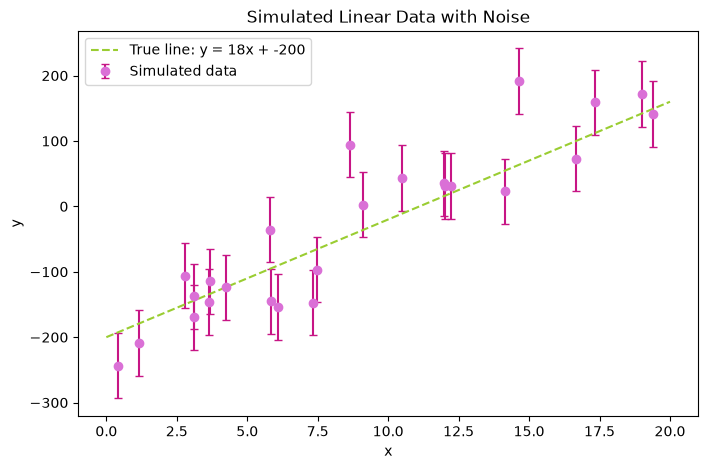

True slope: 18, True intercept: -200


In [78]:
#making my own linear model

np.random.seed(42)

m = 18
b = -200
x = np.random.uniform(0, 20, 25)

noise_std = 50 
noise = np.random.normal(0, noise_std, 25)
y_lin = m * x + b + noise

yerr = np.full(25, noise_std)

plt.figure(figsize=(8, 5))
plt.errorbar(x, y_lin, yerr=yerr, fmt='o', color='orchid', 
             ecolor='mediumvioletred', capsize=3, label='Simulated data')

x_lin = np.linspace(0, 20, 25)
plt.plot(x_lin, m * x_lin + b, color='yellowgreen', 
         linestyle='--', label=f'True line: y = {m}x + {b}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simulated Linear Data with Noise')
plt.legend()
plt.show()

print(f"True slope: {m}, True intercept: {b}")


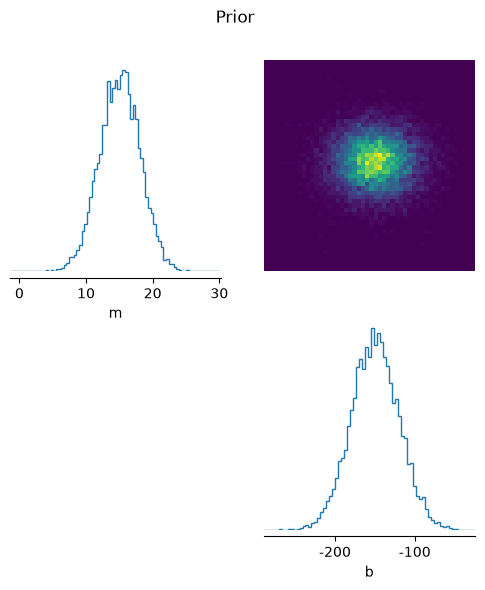

 Neural network successfully converged after 44 epochs.

  0%|          | 0/2000 [00:00<?, ?it/s]

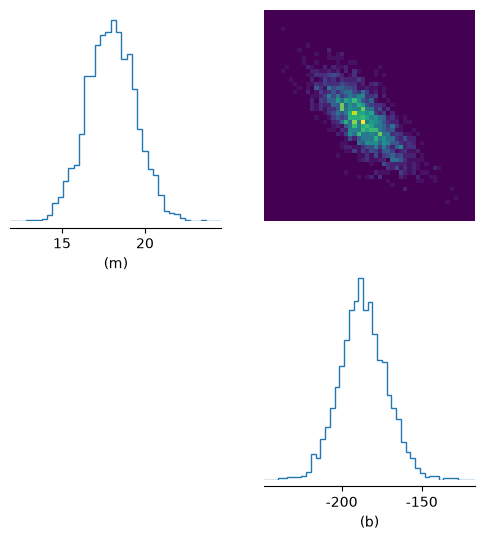

True coefficients: m=18, b=-200
Posterior mean coefficients: m=17.961, b=-186.655


In [79]:
from sbi.analysis import pairplot
from torch.distributions import Normal, Independent

np.random.seed(42)
torch.manual_seed(42)

x = np.random.uniform(0, 20, 25)
noise = np.random.normal(0, noise_std, n_points)
y_observed = m * x + b + noise

prior = Independent(Normal(
    loc=torch.tensor([15.0, -150.0], dtype=torch.float32),
    scale=torch.tensor([3.0, 30.0], dtype=torch.float32)
), 1)

prior_samples = prior.sample((10000,))

fig, ax = pairplot(
    prior_samples,
    labels=["m", "b"],
    figsize=(6, 6)
)
plt.suptitle("Prior")
plt.show()

def simulator(theta):
    coef_a, coef_b, = theta[0].item(), theta[1].item(), 
    sim_noise = np.random.normal(0, noise_std, n_points)
    y_sim = coef_a * x + coef_b  + sim_noise
    return torch.tensor(y_sim, dtype=torch.float32)

n_simulations = 2000
theta_train = prior.sample((n_simulations,))
x_train = torch.stack([simulator(theta) for theta in theta_train])

inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

observation = torch.tensor(y_observed, dtype=torch.float32)
posterior_samples = posterior.sample((2000,), x=observation)


fig, ax = pairplot(
    posterior_samples,
    labels=["(m)", "(b)"],
    figsize=(6, 6)
)
plt.show()

posterior_mean = posterior_samples.mean(dim=0)
print(f"True coefficients: m={m}, b={b}")
print(f"Posterior mean coefficients: m={posterior_mean[0]:.3f}, b={posterior_mean[1]:.3f}")

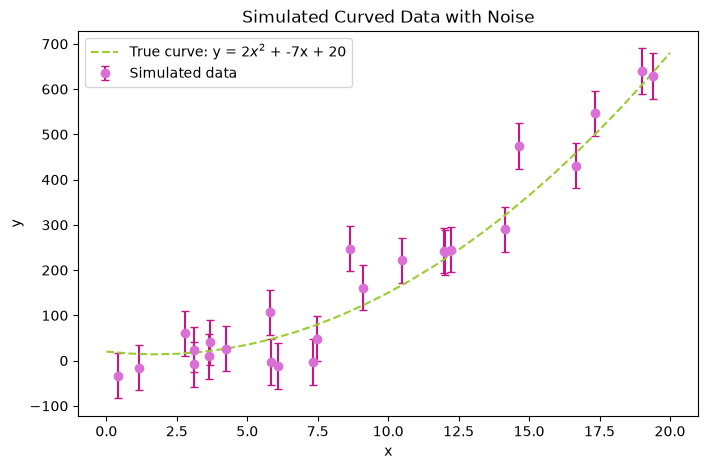

True coefficients: a=2, b=-7, c=20


In [80]:
#making curved data

np.random.seed(42)

a = 2
b = -7
c = 20
x = np.random.uniform(0, 20, 25)

noise_std = 50 
noise = np.random.normal(0, noise_std, 25)
y_curved = a * x**2 + b * x + c + noise

yerr = np.full(25, noise_std)

plt.figure(figsize=(8, 5))
plt.errorbar(x, y_curved, yerr=yerr, fmt='o', color='orchid', 
             ecolor='mediumvioletred', capsize=3, label='Simulated data')
x_lin = np.linspace(0, 20, 25)
plt.plot(x_lin, a * x_lin**2 + b * x_lin + c, color='yellowgreen', 
         linestyle='--', label=f'True curve: y = {a}$x^2$ + {b}x + {c}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simulated Curved Data with Noise')
plt.legend()
plt.show()

print(f"True coefficients: a={a}, b={b}, c={c}")


 Neural network successfully converged after 123 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

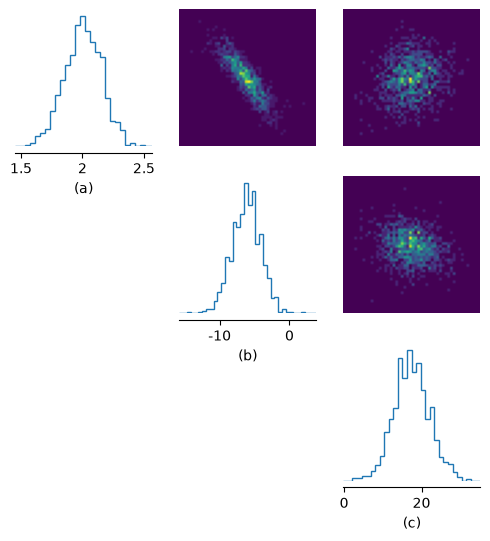

True coefficients: a=2, b=-7, c=20
Posterior mean coefficients: a=2.005, b=-6.223, c=17.394


In [85]:

from sbi.analysis import pairplot

np.random.seed(42)
torch.manual_seed(42)

x = np.random.uniform(0, 20, 25)
noise = np.random.normal(0, noise_std, n_points)
y_observed = a * x**2 + b*x +c + noise

prior = Independent(Normal(
    loc=torch.tensor([5, -5, 18], dtype=torch.float32),
    scale=torch.tensor([3, 2, 5], dtype=torch.float32)
), 1)


def simulator(theta):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, noise_std, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    return torch.tensor(y_sim, dtype=torch.float32)

n_simulations = 2000
theta_train = prior.sample((n_simulations,))
x_train = torch.stack([simulator(theta) for theta in theta_train])

inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

observation = torch.tensor(y_observed, dtype=torch.float32)
posterior_samples = posterior.sample((1000,), x=observation)


fig, ax = pairplot(
    posterior_samples,
    labels=["(a)", "(b)", "(c)"],
    figsize=(6, 6)
)
plt.show()

posterior_mean = posterior_samples.mean(dim=0)
print(f"True coefficients: a={a}, b={b}, c={c}")
print(f"Posterior mean coefficients: a={posterior_mean[0]:.3f}, b={posterior_mean[1]:.3f}, c={posterior_mean[2]:.3f}")

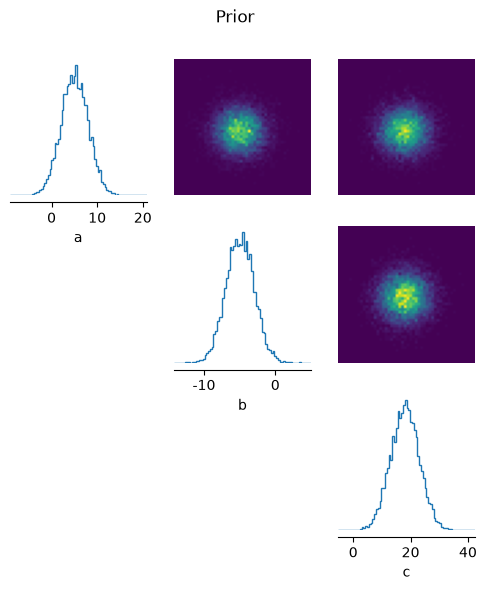

In [86]:
#plot the prior distribution

prior = Independent(Normal(
    loc=torch.tensor([5, -5, 18], dtype=torch.float32),
    scale=torch.tensor([3, 2, 5], dtype=torch.float32)
), 1)

prior_samples = prior.sample((10000,))

fig, ax = pairplot(
    prior_samples,
    labels=["a", "b", "c"],
    figsize=(6, 6)
)
plt.suptitle("Prior")
plt.show()


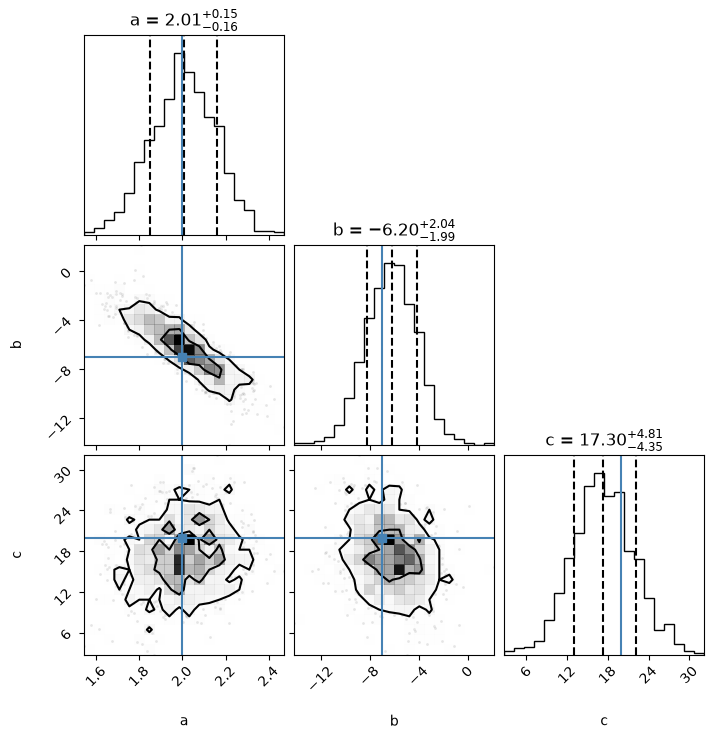

In [87]:
#Make corner plot
flat_samples = posterior_samples.numpy()

a = 2
b = -7
c = 20
labels = ["a", "b", "c"]
truths = [a, b, c]

fig = cp.corner(flat_samples[:, :3], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})